# Análise Exploratória: Terremotos

Dataset: [All the Earthquakes Dataset : from 1990-2023](https://www.kaggle.com/datasets/alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023)

---

Ciência de Dados - 08N

João Pedro Rodrigues Vieira - RA 10403595

---

O dataset coletado reúne dados históricos de terremotos observados mundialmente ao longo dos anos 1990 e 2023. São aproximadamente 3 milhões de linhas, contendo informações sobre:
- time: tempo em milissegundos;
- place: local onde ocorreu o terremoto;
- status: status de revisão do registro (ex: "automatic" se foi gerado por algoritmos sem revisão, ou "reviewed" se foi analisado e validado por um sismólogo humano);
- tsunami (booleano): indica se o evento gerou um alerta ou um evento de tsunami (1 para sim, 0 para não);
- significance: índice que mede o impacto humano e estrutural do evento;
- data_type: tipo específico do evento registrado (ex: "earthquake" para terremoto natural, "quarry blast" para explosão em pedreira, "ice quake", etc.);
- magnitudo: medida física e objetiva da energia total liberada pelo tremor na sua origem (como a Escala Richter ou de Momento);
- state: estado, província ou região administrativa principal onde o evento ocorreu;
- longitude: coordenada geográfica Leste-Oeste do epicentro na superfície da Terra;
- latitude: coordenada geográfica Norte-Sul do epicentro na superfície da Terra;
- depth: profundidade (em quilômetros) entre a superfície e o ponto exato de ruptura no subsolo (o hipocentro);
- date: data e hora do evento em um formato legível para humanos (ex: YYYY-MM-DD HH:MM:SS),

## 0. Preparando o Ambiente

In [16]:
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;

In [2]:
df = pd.read_csv("Eartquakes-1990-2023.csv");
df.head()

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


## 1. Resumo Quantitativo e Descrição dos Dados

In [3]:
# Elencando todas as colunas presentes no dataset, visualizando quais são qualitativas ou quantitativas
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3445751 entries, 0 to 3445750
Data columns (total 12 columns):
 #   Column        Dtype  
---  ------        -----  
 0   time          int64  
 1   place         object 
 2   status        object 
 3   tsunami       int64  
 4   significance  int64  
 5   data_type     object 
 6   magnitudo     float64
 7   state         object 
 8   longitude     float64
 9   latitude      float64
 10  depth         float64
 11  date          object 
dtypes: float64(4), int64(3), object(5)
memory usage: 315.5+ MB


In [4]:
# Resumo quantitativo do dataset
# 25% e 75% equivalem aos quartis Q1 e Q3, ao passo que 50% significa a própria mediana

# Transformando o tipo de dado Series, que é retornado do método .var(), em um dataframe
var_df = df.var(numeric_only=True).to_frame(name="var").T;

# Unindo os valores de variância, agora um dataframe, aos retornados pelo .describe()
describe_df = pd.concat([df.describe(), var_df]);

# Adicionando uma linha para o intervalo interquartil (iqr)
describe_df.loc["iqr"] = describe_df.loc["75%"] - describe_df.loc["25%"];

# Calculando a amplitude (máximo - mínimo)
describe_df.loc["range"] = describe_df.loc["max"] - describe_df.loc["min"];

describe_df

,time,tsunami,significance,magnitudo,longitude,latitude,depth
count,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06
mean,1.247124e+12,4.434447e-04,7.400973e+01,1.774076e+00,-1.012876e+02,3.746483e+01,2.285387e+01
std,2.976292e+11,2.105346e-02,1.016364e+02,1.291055e+00,7.697416e+01,2.041577e+01,5.484938e+01
min,6.311534e+11,0.000000e+00,0.000000e+00,-9.990000e+00,-1.799997e+02,-8.442200e+01,-1.000000e+01
25%,1.024401e+12,0.000000e+00,1.300000e+01,9.100000e-01,-1.464274e+02,3.406400e+01,3.120000e+00
50%,1.282338e+12,0.000000e+00,3.300000e+01,1.460000e+00,-1.189538e+02,3.793567e+01,7.700000e+00
75%,1.508701e+12,0.000000e+00,8.100000e+01,2.300000e+00,-1.159277e+02,4.784800e+01,1.612000e+01
max,1.690629e+12,1.000000e+00,2.910000e+03,9.100000e+00,1.800000e+02,8.738600e+01,7.358000e+02
var,8.858316e+22,4.432482e-04,1.032996e+04,1.666823e+00,5.925021e+03,4.168035e+02,3.008454e+03
iqr,4.842996e+11,0.000000e+00,6.800000e+01,1.390000e+00,3.049973e+01,1.378400e+01,1.300000e+01


### 1.2. Variáveis Qualitativas

In [5]:
# Estas são as colunas contendo variáveis categóricas

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index(['place', 'status', 'data_type', 'state', 'date'], dtype='object')

In [6]:
for col in categorical_cols:
    df[col] = df[col].str.upper()

df[categorical_cols].head()

,place,status,data_type,state,date
0,"12 KM NNW OF MEADOW LAKES, ALASKA",REVIEWED,EARTHQUAKE,ALASKA,1990-01-01 00:22:33.990000+00:00
1,"14 KM S OF VOLCANO, HAWAII",REVIEWED,EARTHQUAKE,HAWAII,1990-01-01 00:24:51.210000+00:00
2,"7 KM W OF COBB, CALIFORNIA",REVIEWED,EARTHQUAKE,CALIFORNIA,1990-01-01 00:34:43.450000+00:00
3,"11 KM E OF MAMMOTH LAKES, CALIFORNIA",REVIEWED,EARTHQUAKE,CALIFORNIA,1990-01-01 00:58:32.130000+00:00
4,"16KM N OF FILLMORE, CA",REVIEWED,EARTHQUAKE,CALIFORNIA,1990-01-01 01:03:44.490000+00:00


#### 1.2.1 Place

In [7]:
absolute_count = df["place"].value_counts();
relative_count = (df["place"].value_counts(normalize=True) * 100).round(2);

freq_df = pd.DataFrame({
    "absolute frequency": absolute_count,
    "relative frequency": relative_count,
});

freq_df

,absolute frequency,relative frequency
place,,
"6 KM W OF COBB, CALIFORNIA",24202,0.70
"7 KM W OF COBB, CALIFORNIA",23821,0.69
"8 KM W OF COBB, CALIFORNIA",15288,0.44
"37 KM NNE OF AMBOY, WASHINGTON",14373,0.42
"9 KM W OF COBB, CALIFORNIA",11146,0.32
...,...,...
"10 KM WSW OF PÉRDIKA, GREECE",1,0.00
"19 KM NNE OF LANCE CREEK, WYOMING",1,0.00
"25 KM E OF FORKS, WASHINGTON",1,0.00


#### 1.2.2. Status

In [8]:
absolute_count = df["status"].value_counts();
relative_count = (df["status"].value_counts(normalize=True) * 100).round(2);

freq_df = pd.DataFrame({
    "absolute frequency": absolute_count,
    "relative frequency": relative_count,
});


freq_df

,absolute frequency,relative frequency
status,,
REVIEWED,3238918,94.0
AUTOMATIC,206821,6.0
MANUAL,12,0.0


#### 1.2.3. Data Type

In [9]:
absolute_count = df["data_type"].value_counts();
relative_count = (df["data_type"].value_counts(normalize=True) * 100).round(2);

freq_df = pd.DataFrame({
    "absolute frequency": absolute_count,
    "relative frequency": relative_count,
});

freq_df

,absolute frequency,relative frequency
data_type,,
EARTHQUAKE,3361846,97.56
QUARRY BLAST,38865,1.13
EXPLOSION,26571,0.77
ICE QUAKE,13839,0.40
MINING EXPLOSION,2177,0.06
OTHER EVENT,1706,0.05
CHEMICAL EXPLOSION,314,0.01
ROCK BURST,182,0.01
SONIC BOOM,104,0.00


#### 1.2.4. State

In [10]:
absolute_count = df["state"].value_counts();
relative_count = (df["state"].value_counts(normalize=True) * 100).round(2);

freq_df = pd.DataFrame({
    "absolute frequency": absolute_count,
    "relative frequency": relative_count,
});

freq_df

,absolute frequency,relative frequency
state,,
CALIFORNIA,866675,25.15
ALASKA,777881,22.58
CALIFORNIA,491689,14.27
NEVADA,174065,5.05
HAWAII,125336,3.64
...,...,...
MALTA REGION,1,0.00
ERITREA-ETHIOPIA BORDER REGION,1,0.00
MADAGASCAR,1,0.00


#### 1.2.5. Date

In [11]:
absolute_count = df["date"].value_counts();
relative_count = (df["date"].value_counts(normalize=True) * 100).round(2);

freq_df = pd.DataFrame({
    "absolute frequency": absolute_count,
    "relative frequency": relative_count,
});

freq_df

,absolute frequency,relative frequency
date,,
2022-03-02 23:42:23.449000+00:00,4,0.0
2022-03-01 04:29:53.805000+00:00,4,0.0
1999-11-30 00:00:00+00:00,3,0.0
2013-03-01 09:40:34.455000+00:00,2,0.0
2013-03-01 09:47:09.276000+00:00,2,0.0
...,...,...
2005-02-16 23:09:08.430000+00:00,1,0.0
2005-02-16 23:10:11.560000+00:00,1,0.0
2005-02-16 23:15:15.837000+00:00,1,0.0


## 2. Análise de Correlação

Segundo o [Geeks For Geeks](https://www.geeksforgeeks.org/maths/pearson-correlation-coefficient/):

> Assumptions of Pearson Correlation Coefficient
> 1. Linear Relationship: Pearson’s correlation assumes a linear relationship between the two variables. Non-linear relationships may not be accurately captured.
> 2. Normality: The variables should follow a normal distribution. This helps ensure that the correlation is meaningful and not affected by skewed data.
> 3. Homoscedasticity: The variability in one variable should remain consistent across all values of the other variable. This means the spread of data should be uniform.
> 4. Interval or Ratio Scale: Pearson’s correlation is appropriate for interval or ratio data that are continuous and have consistent, meaningful numerical differences.
> 5. Independence: Observations should be independent of each other which means one data point should not influence another. Dependent data points can distort the correlation.

In [28]:
# Averiguando valores contínuos
df.corr(method="pearson", numeric_only=True)

,time,tsunami,significance,magnitudo,longitude,latitude,depth
time,1.000000,0.018810,-0.079786,-0.119291,-0.118873,0.105484,0.031901
tsunami,0.018810,1.000000,0.093231,0.057237,0.006030,-0.001151,0.009602
significance,-0.079786,0.093231,1.000000,0.939378,0.651201,-0.556973,0.363232
magnitudo,-0.119291,0.057237,0.939378,1.000000,0.590835,-0.494491,0.356990
longitude,-0.118873,0.006030,0.651201,0.590835,1.000000,-0.457686,0.171687
latitude,0.105484,-0.001151,-0.556973,-0.494491,-0.457686,1.000000,-0.236342
depth,0.031901,0.009602,0.363232,0.356990,0.171687,-0.236342,1.000000


In [25]:
pcc = df["magnitudo"].corr(df["depth"], method="pearson")
print(f"O coeficiente de correlação de Pearson entre magnitude de terremoto e sua profundidade é de: {pcc}")

O coeficiente de correlação de Pearson entre magnitude de terremoto e sua profundidade é de: 0.3569899099108273


In [29]:
# Verificando todas as correlações existentes
df.corr(method="pearson", numeric_only=True)

,time,tsunami,significance,magnitudo,longitude,latitude,depth
time,1.000000,0.018810,-0.079786,-0.119291,-0.118873,0.105484,0.031901
tsunami,0.018810,1.000000,0.093231,0.057237,0.006030,-0.001151,0.009602
significance,-0.079786,0.093231,1.000000,0.939378,0.651201,-0.556973,0.363232
magnitudo,-0.119291,0.057237,0.939378,1.000000,0.590835,-0.494491,0.356990
longitude,-0.118873,0.006030,0.651201,0.590835,1.000000,-0.457686,0.171687
latitude,0.105484,-0.001151,-0.556973,-0.494491,-0.457686,1.000000,-0.236342
depth,0.031901,0.009602,0.363232,0.356990,0.171687,-0.236342,1.000000


O resultado acima aponta para uma moderada/fraca relação positiva entre magnitude e a profundidade de um terremoto. Isto indica que, quanto maior a magnitude de um terremoto, possivelmente a distância entre a ruptura subterrânea que gerou o terremoto e a superfície da terra.

## 3. Visualização dos Dados

### 3.1. Histograma

In [17]:
numerical_cols = df.select_dtypes(exclude=["object", "category"]).columns

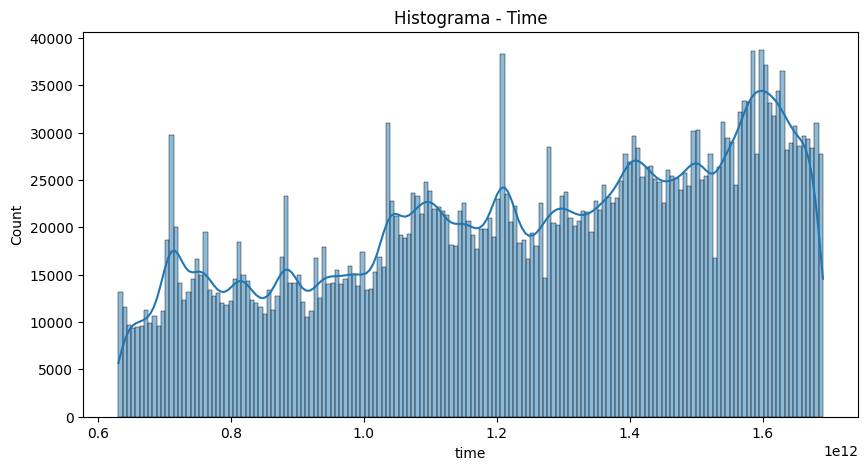

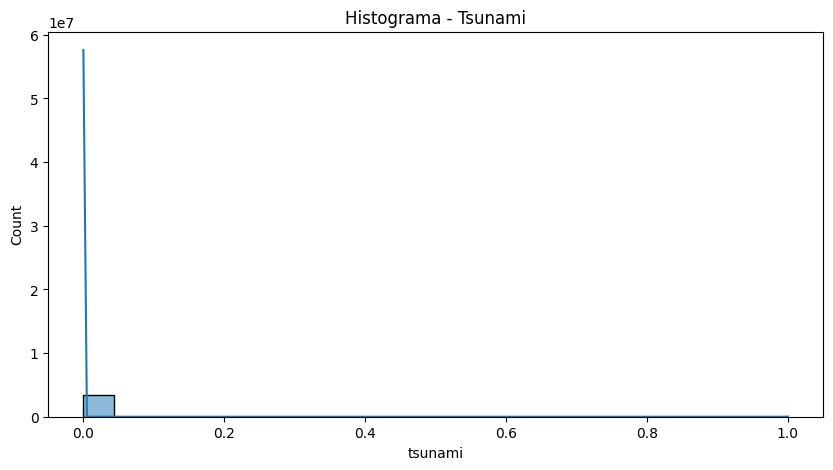

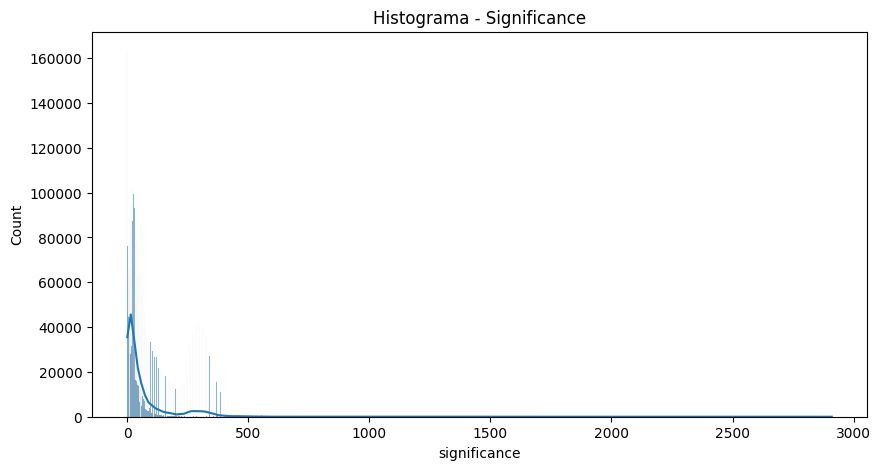

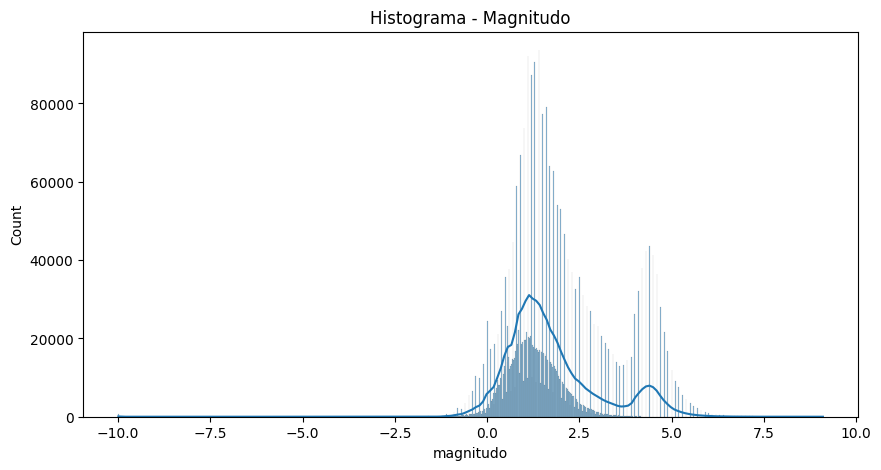

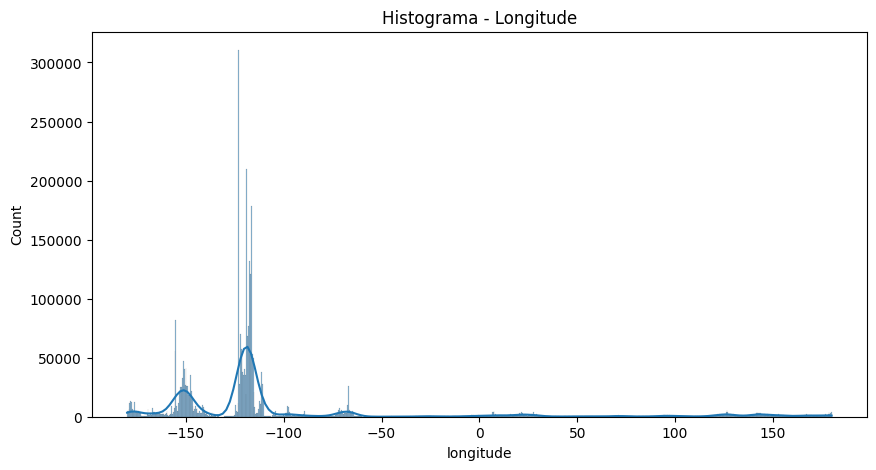

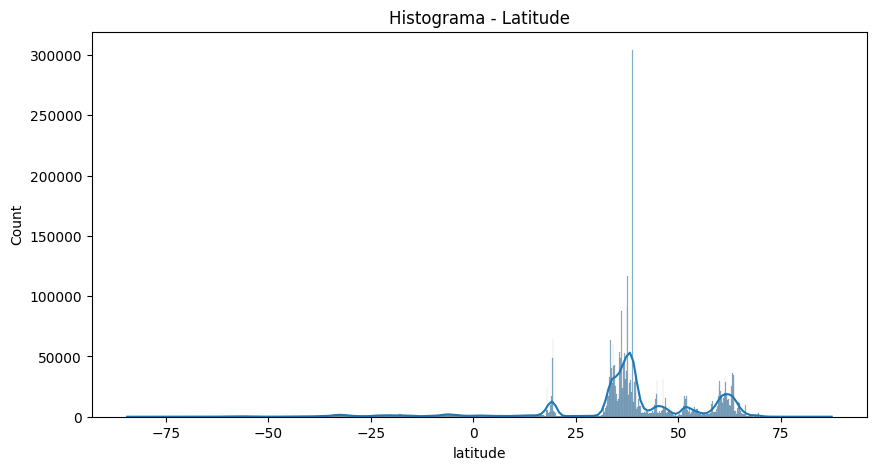

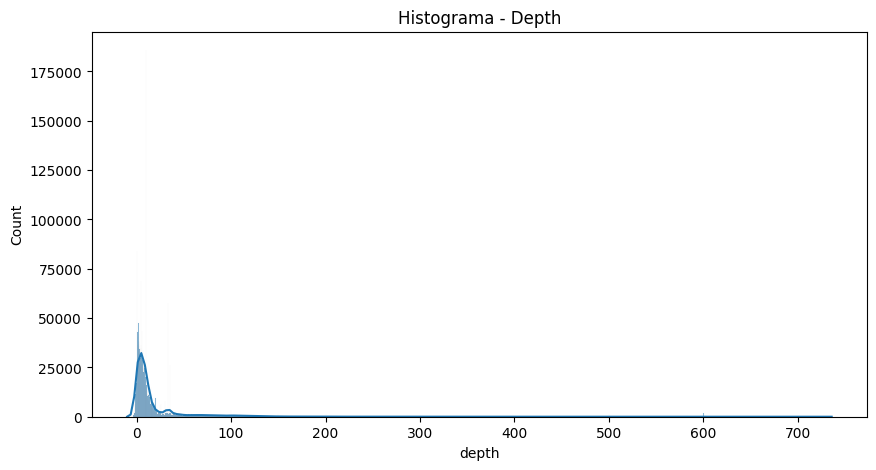

In [20]:
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histograma - {col.capitalize()}")
    plt.show()

### 3.2. Diagrama de Caixa (BoxPlot)

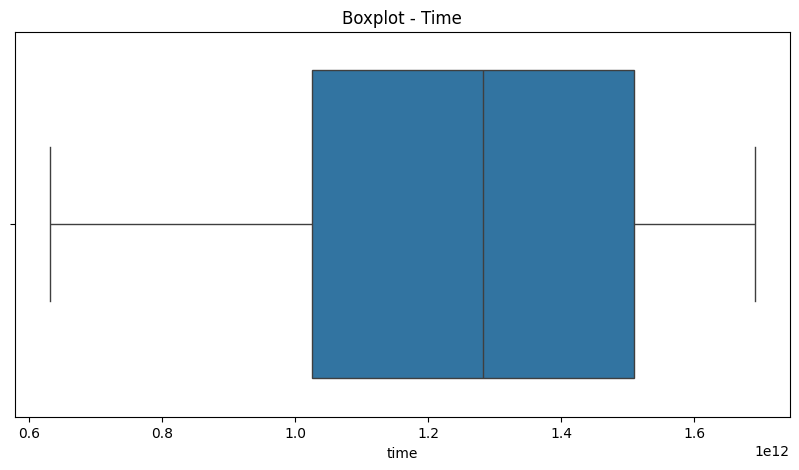

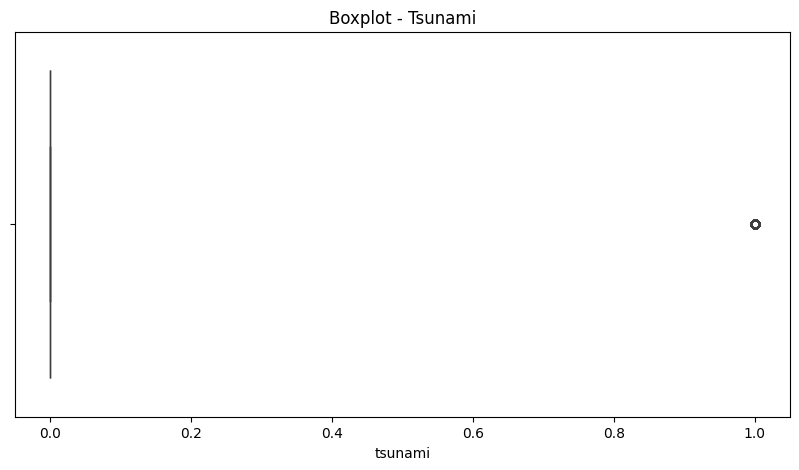

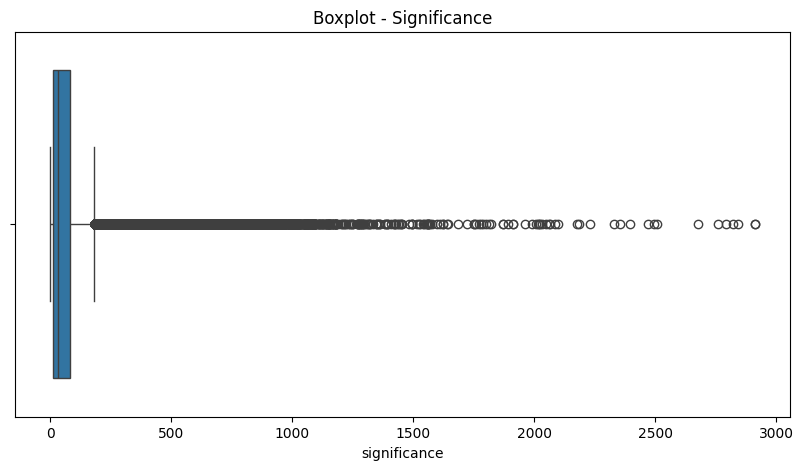

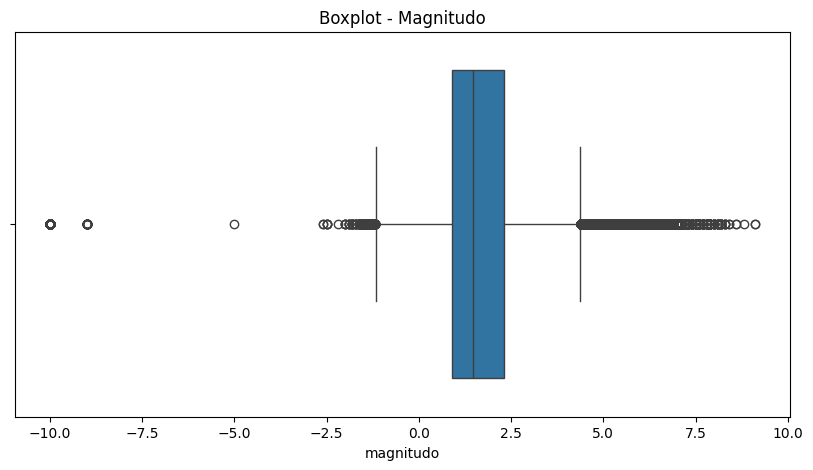

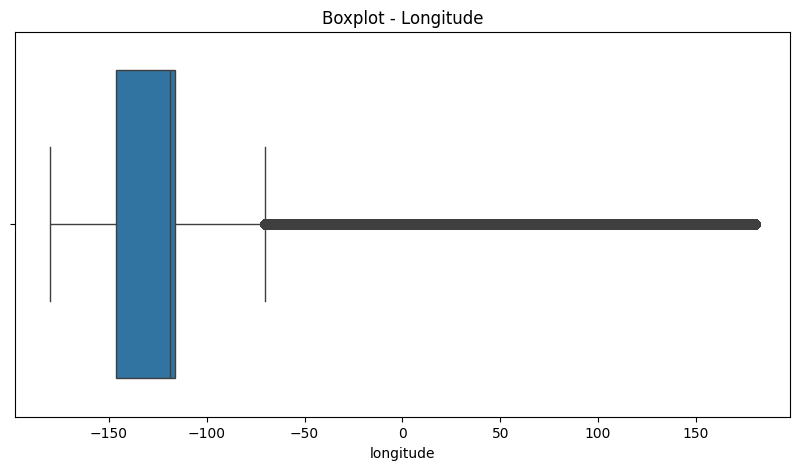

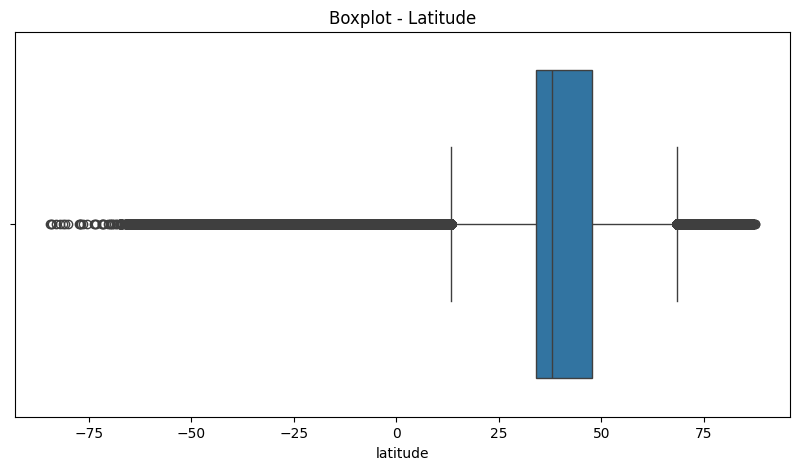

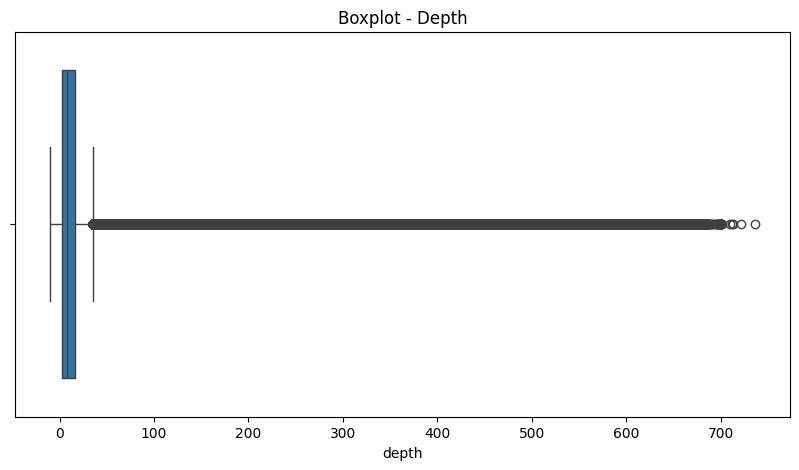

In [21]:
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col.capitalize()}")
    plt.show()

### 3.3. Diagrama de Dispersão

Text(0.5, 1.0, 'Gráfico de Dispersão Magnitude x Profundidade')

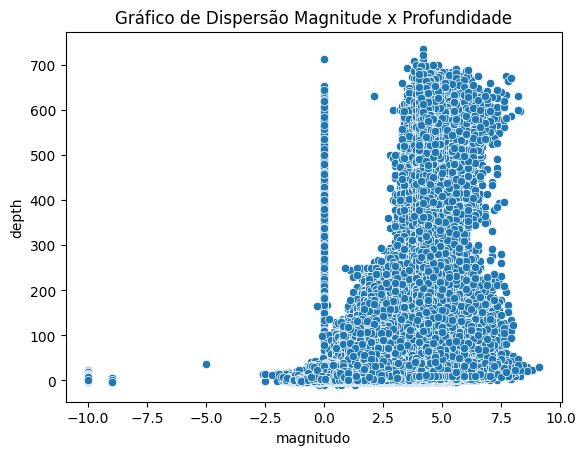

In [27]:
sns.scatterplot(data=df, x=df["magnitudo"], y=df["depth"])
plt.title("Gráfico de Dispersão Magnitude x Profundidade")

## 4. Insights e Hipóteses

---

Os efeitos práticos de uma catástrofe como o terremoto são amplamente conhecidos pela sociedade em razão de sua característica destrutiva. Por este motivo, correlações fortes como magnitude do terremoto e sua significância (o quão impactante foi para as civilizações atingidas) são correlações razoáveis. Sobre a correlação analisada (magnitude x profundidade), percebe-se que maiores profundidades de origem do terremoto não acarretam necessariamente em perdas significativas de magnitude. Ou seja, o que se poderia pensar sobre uma possível "perda de energia" em função da distância não ocorre. Pelo contrário, foi observada uma correlação positiva moderada/fraca entre estas duas variáveis. No entanto, ainda pensando na conservação de energia, uma hipótese que pode ser levantada é a de que, ainda assim, os terremotos de maior magnitude ocorreram somente em profundidades rasas, seja por razões de conservação de energia, seja por outros fatores geológicos.